# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.



C:\Users\jedij\AppData\Local\Temp\ipykernel_30012\3095584991.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='person_gender', y='loan_status', ax=axes[0, 0], errorbar=None, palette='viridis')
C:\Users\jedij\AppData\Local\Temp\ipykernel_30012\3095584991.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='person_age', ax=axes[0, 1], palette='coolwarm')
C:\Users\jedij\AppData\Local\Temp\ipykernel_30012\3095584991.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='perso

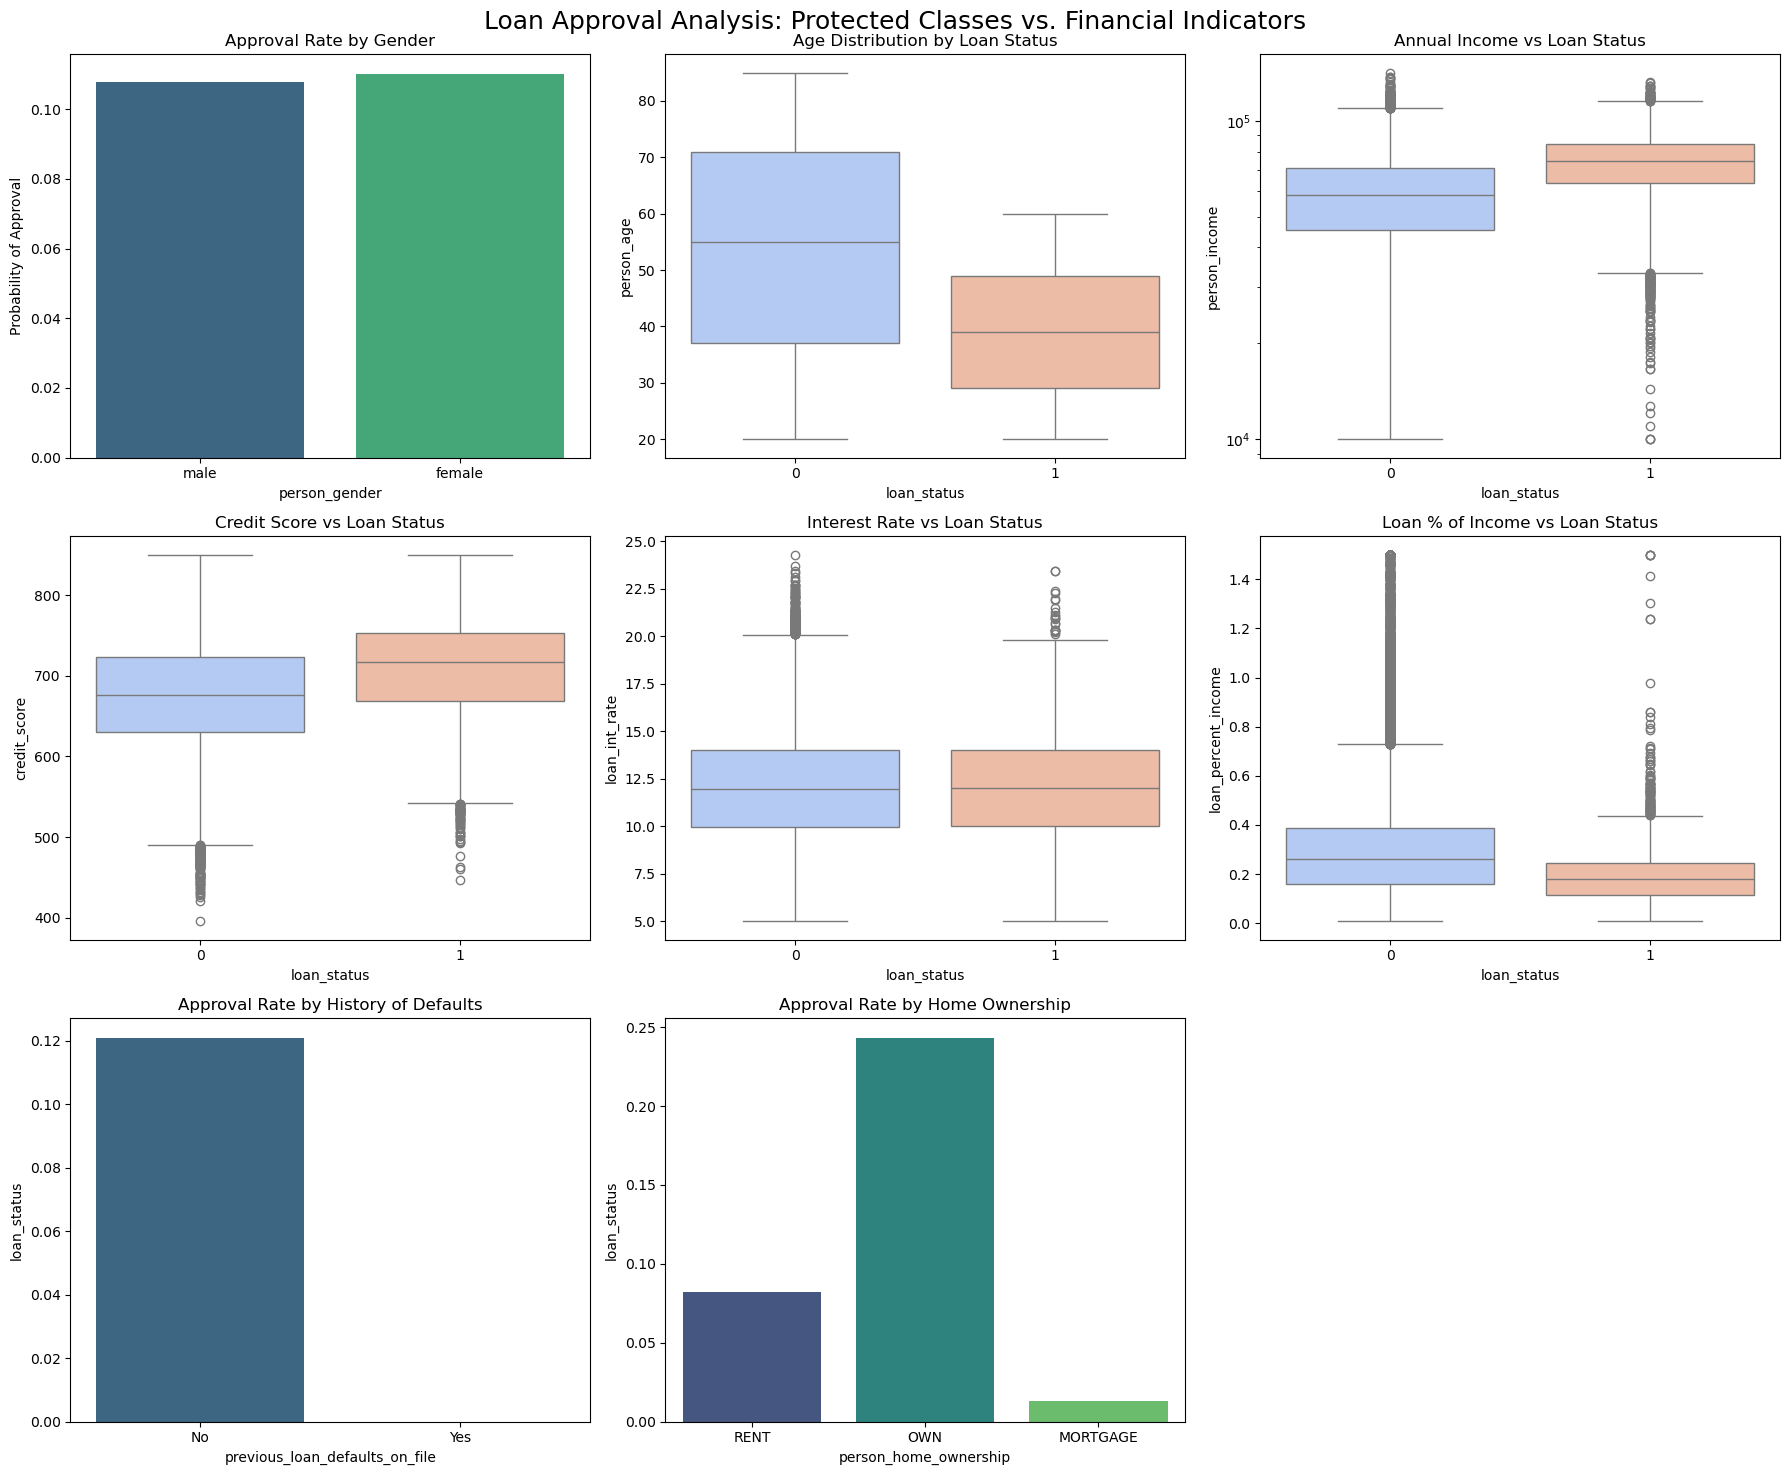

Approval Rate by Gender:
person_gender
female    0.110280
male      0.107711
Name: loan_status, dtype: float64

Average Age by Loan Status:
loan_status
0    54.021318
1    39.482117
Name: person_age, dtype: float64


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('loan_data.csv')

# 2. Set up the figure with multiple subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Loan Approval Analysis: Protected Classes vs. Financial Indicators', fontsize=18)

# --- Protected Classes (The Legal Questions) ---

# Plot 1: Sex vs Loan Status (Categorical)
# Shows the approval rate (percentage) for each gender
sns.barplot(data=df, x='person_gender', y='loan_status', ax=axes[0, 0], errorbar=None, palette='viridis')
axes[0, 0].set_title('Approval Rate by Gender')
axes[0, 0].set_ylabel('Probability of Approval')

# Plot 2: Age vs Loan Status (Numerical)
# Boxplot shows the distribution of ages for Approved (1) vs Rejected (0)
sns.boxplot(data=df, x='loan_status', y='person_age', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Age Distribution by Loan Status')

# --- Financial Indicators (The Likely Drivers) ---

# Plot 3: Income vs Loan Status
# Using a log scale for income to make the chart readable (incomes vary wildly)
sns.boxplot(data=df, x='loan_status', y='person_income', ax=axes[0, 2], palette='coolwarm')
axes[0, 2].set_yscale('log') 
axes[0, 2].set_title('Annual Income vs Loan Status')

# Plot 4: Credit Score vs Loan Status
sns.boxplot(data=df, x='loan_status', y='credit_score', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Credit Score vs Loan Status')

# Plot 5: Loan Interest Rate vs Loan Status
sns.boxplot(data=df, x='loan_status', y='loan_int_rate', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Interest Rate vs Loan Status')

# Plot 6: Loan Percent of Income vs Loan Status
sns.boxplot(data=df, x='loan_status', y='loan_percent_income', ax=axes[1, 2], palette='coolwarm')
axes[1, 2].set_title('Loan % of Income vs Loan Status')

# Plot 7: Previous Defaults vs Loan Status
sns.barplot(data=df, x='previous_loan_defaults_on_file', y='loan_status', ax=axes[2, 0], errorbar=None, palette='viridis')
axes[2, 0].set_title('Approval Rate by History of Defaults')

# Plot 8: Home Ownership vs Loan Status
sns.barplot(data=df, x='person_home_ownership', y='loan_status', ax=axes[2, 1], errorbar=None, palette='viridis')
axes[2, 1].set_title('Approval Rate by Home Ownership')

# Hide the empty 9th subplot
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

# --- Statistics for Report ---
print("Approval Rate by Gender:")
print(df.groupby('person_gender')['loan_status'].mean())
print("\nAverage Age by Loan Status:")
print(df.groupby('loan_status')['person_age'].mean())

A major driver of people getting a loan is the loan percent of income. The model tends to favor those whoa re not over-leveraged.

Having a higher income has a high dictation that larger lones will be approved.

interest rates seem negligable in terms of difference meaning the mean of each group(accepted or rejected) is around the same. 

Legal Concerns:

I can see a legal concern with Age. People who are older seem to have a harder time with getting loans. The mean of the accepted is of younger people who i believe are just getting into the loans. It almost seems predatorial.